<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/Data-Analysis-Project/blob/main/product_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. IMPORT DATA AND OVERVIEW

In [3]:
# ==========================================
# CELL 1: SETUP & IMPORT
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('product_sales_dataset_final.csv')

# Clean column names: remove leading/trailing whitespace
df.columns = df.columns.str.strip()

# 2. Define column lists
categorical_cols = ['Region', 'Country', 'Item_Type', 'Sales_Channel', 'Order_Priority',
                    'Category', 'Sub_Category', 'Customer_Name', 'City', 'State', 'Product_Name']
numerical_cols = ['Order_ID', 'Quantity', 'Unit_Price', 'Revenue', 'Profit']

# 3. Data Type Conversion (FIX: Ensure non-null data)
# Use flexible datetime parsing to let Pandas automatically detect the date format
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# Convert categorical columns to the 'category' data type for efficiency
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Enforce numeric types for calculation-heavy columns (Revenue, Profit, etc.)
for col in numerical_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("--- Sales Data Structure Successfully Initialized ---")
df.info()

# Display the first 5 rows to verify 'Order_Date' conversion
print("\nVerifying 'Order_Date' (First 5 Rows):")
print(df[['Order_Date']].head())

--- Sales Data Structure Successfully Initialized ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Order_ID       200000 non-null  int64         
 1   Order_Date     200000 non-null  datetime64[ns]
 2   Customer_Name  200000 non-null  category      
 3   City           200000 non-null  category      
 4   State          200000 non-null  category      
 5   Region         200000 non-null  category      
 6   Country        200000 non-null  category      
 7   Category       200000 non-null  category      
 8   Sub_Category   200000 non-null  category      
 9   Product_Name   200000 non-null  category      
 10  Quantity       200000 non-null  int64         
 11  Unit_Price     200000 non-null  float64       
 12  Revenue        200000 non-null  float64       
 13  Profit         200000 non-null  float64       
dty

In [4]:
# ==========================================
# CELL 2: DATA OVERVIEW
# ==========================================
print(f"\nDataset Dimensions (Rows, Columns): {df.shape}")

# 1. Number Formatting: Thousands separator and 2 decimal places for better readability
pd.options.display.float_format = '{:,.2f}'.format

print("\nDescriptive Statistics (Numerical Data):")
# Display summary statistics for the numerical columns defined in Cell 1
display(df[numerical_cols].describe())

print("\nMissing Values Check:")
# Check all columns to ensure data integrity and cleanliness
print(df.isnull().sum())

print("\nFirst 5 Rows of Data:")
# Display the head of the dataframe to verify all 14 columns (including Order_ID)
display(df.head())


Dataset Dimensions (Rows, Columns): (200000, 14)

Descriptive Statistics (Numerical Data):


,Order_ID,Quantity,Unit_Price,Revenue,Profit
count,"200,000.00","200,000.00","200,000.00","200,000.00","200,000.00"
mean,"100,000.50",1.85,382.86,712.04,157.74
std,"57,735.17",1.10,276.87,742.47,155.69
min,1.00,1.00,17.03,17.03,3.92
25%,"50,000.75",1.00,162.76,229.19,59.21
50%,"100,000.50",1.00,303.55,464.88,109.53
75%,"150,000.25",2.00,562.25,881.30,199.40
max,"200,000.00",11.00,"1,432.00","9,014.25","2,763.72"



Missing Values Check:
Order_ID         0
Order_Date       0
Customer_Name    0
City             0
State            0
Region           0
Country          0
Category         0
Sub_Category     0
Product_Name     0
Quantity         0
Unit_Price       0
Revenue          0
Profit           0
dtype: int64

First 5 Rows of Data:


,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,2023-08-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,2024-12-20,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,2024-01-29,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,2024-11-29,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,2023-09-21,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46


2. DATA CLEANING & OPTIMIZATION







In [5]:
# ==========================================
# HANDLING DUPLICATES
# ==========================================
# Check for exact duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Number of initial duplicate rows: {num_duplicates}")

# Remove duplicate rows, keeping the first occurrence
initial_rows_count = df.shape[0]
df.drop_duplicates(inplace=True)
rows_after_duplicate_removal = df.shape[0]

print(f"Number of rows after duplicate removal: {rows_after_duplicate_removal}")
print(f"=> Removed {initial_rows_count - rows_after_duplicate_removal} duplicate rows.")

# ==========================================
# HANDLING MISSING VALUES
# ==========================================
# Display all current column names for confirmation
print("\nCurrent DataFrame columns:")
print(df.columns)

# Check for missing values in 'Unit_Price' and 'Quantity'
print("\nMissing values before cleaning ('Unit_Price' and 'Quantity'):")
print(df[['Unit_Price', 'Quantity']].isnull().sum())

# Handling Strategy: In sales data, if 'Unit_Price' or 'Quantity' is missing,
# Revenue/Profit cannot be accurately calculated. It is best to remove these rows.
rows_before_dropna = df.shape[0]
df.dropna(subset=['Unit_Price', 'Quantity'], inplace=True)
rows_after_dropna = df.shape[0]

# Re-verify dataset dimensions after final cleaning
print(f"\nFinal dataset dimensions after cleaning: {df.shape}")
print(f"=> Removed {rows_before_dropna - rows_after_dropna} rows with missing 'Unit_Price' or 'Quantity'.")
print("Missing values after cleaning:")
print(df[['Unit_Price', 'Quantity']].isnull().sum())

Number of initial duplicate rows: 0
Number of rows after duplicate removal: 200000
=> Removed 0 duplicate rows.

Current DataFrame columns:
Index(['Order_ID', 'Order_Date', 'Customer_Name', 'City', 'State', 'Region',
       'Country', 'Category', 'Sub_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Revenue', 'Profit'],
      dtype='object')

Missing values before cleaning ('Unit_Price' and 'Quantity'):
Unit_Price    0
Quantity      0
dtype: int64

Final dataset dimensions after cleaning: (200000, 14)
=> Removed 0 rows with missing 'Unit_Price' or 'Quantity'.
Missing values after cleaning:
Unit_Price    0
Quantity      0
dtype: int64


-- EXPORT CLEANED DATASET --

In [7]:
df.to_csv('product_sales_cleaned.csv', index=False)
print("Cleaned file successfully created: product_sales_cleaned.csv")

Cleaned file successfully created: product_sales_cleaned.csv


3. ADVANCED ANALYTICS

-- FORECAST REPORT 2025--





╔══════════════════════════════════════════════════════════╗
               2025 FINANCIAL FORECAST REPORT               
╠══════════════════════════════════════════════════════════╣
  ▶ Total Estimated Revenue:              72.55 M$  
  ▶ Total Estimated Profit:               16.06 M$  
  ▶ Average Profit Margin:                22.14 %   
╚══════════════════════════════════════════════════════════╝

MONTHLY FORECAST DETAILS:
----------------------------------------------
Year/Month  Revenue($M)  Profit($M)  Margin(%)
   2025/01         4.49        1.00      22.19
   2025/02         2.96        0.66      22.33
   2025/03         4.10        0.91      22.22
   2025/04         4.42        0.97      22.04
   2025/05         4.98        1.10      22.18
   2025/06         4.82        1.07      22.23
   2025/07         4.55        1.00      22.07
   2025/08         4.52        0.99      21.90
   2025/09         4.85        1.07      22.17
   2025/10         8.81        1.96      22.19
   20

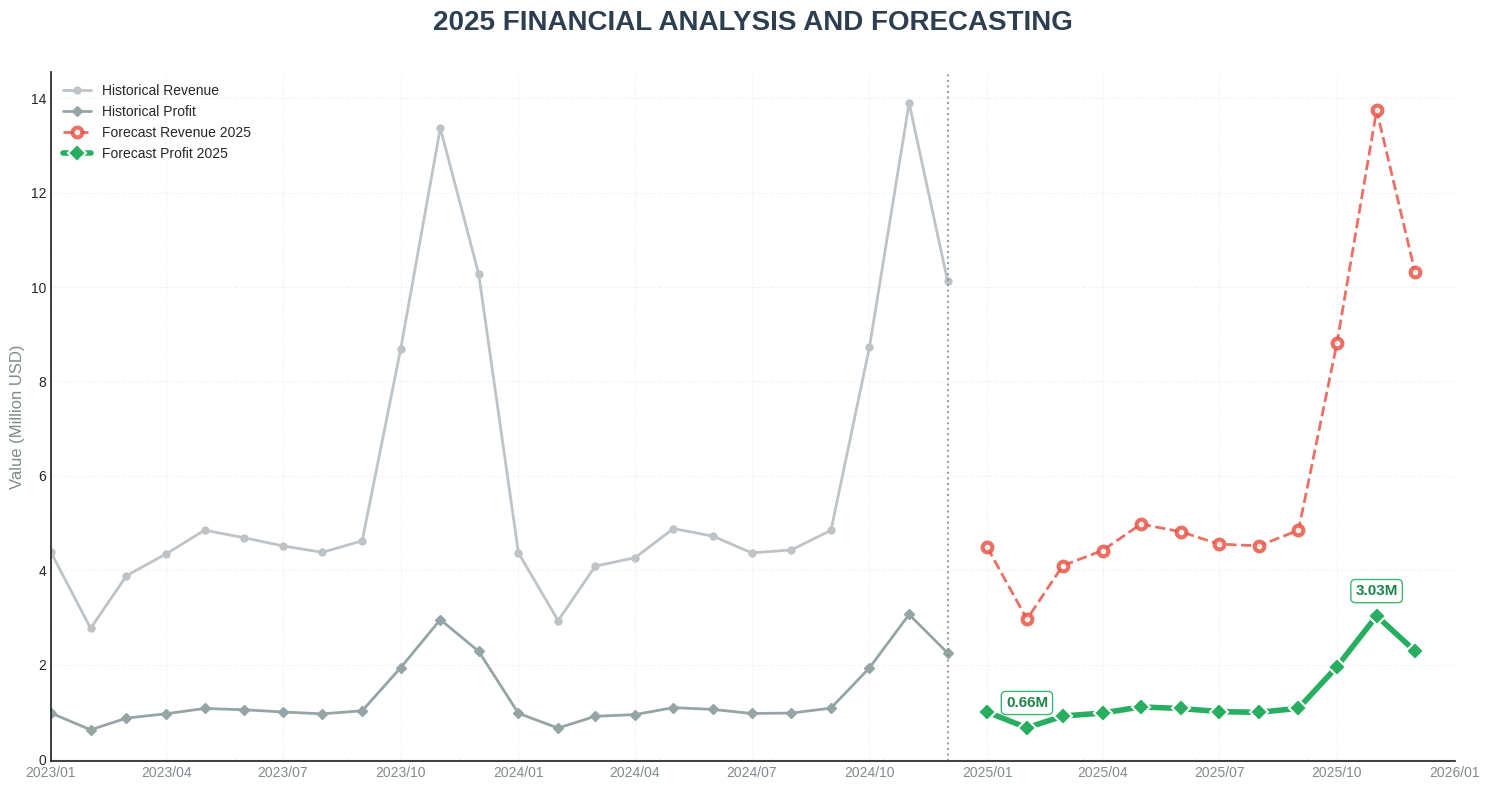

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression

# ==========================================
# MONTHLY DATA AGGREGATION & FORECASTING
# ==========================================

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df = df.sort_values(by='Order_Date')

monthly = df.set_index('Order_Date').resample('MS').agg({
    'Revenue': 'sum',
    'Profit': 'sum'
}).reset_index()

monthly['Revenue_M'] = monthly['Revenue'] / 1_000_000
monthly['Profit_M'] = monthly['Profit'] / 1_000_000

monthly['Time_Index'] = np.arange(len(monthly))
X_hist = pd.get_dummies(monthly['Order_Date'].dt.month, prefix='Month')
X_hist['Time_Index'] = monthly['Time_Index']

model_rev = LinearRegression().fit(X_hist, monthly['Revenue_M'])
model_pro = LinearRegression().fit(X_hist, monthly['Profit_M'])

future_dates = pd.date_range(start='2025-01-01', periods=12, freq='MS')
future_months = pd.Series(future_dates.month)

X_future_dummies = pd.get_dummies(future_months, prefix='Month')

future_time_index_start = monthly['Time_Index'].max() + 1
X_future_time_index = pd.Series(np.arange(future_time_index_start, future_time_index_start + 12), index=X_future_dummies.index, name='Time_Index')

X_future_temp = pd.concat([X_future_dummies, X_future_time_index], axis=1)

X_future = X_future_temp.reindex(columns=X_hist.columns, fill_value=0)

y_rev_2025 = model_rev.predict(X_future)
y_pro_2025 = model_pro.predict(X_future)

# --- 1. CALCULATE SUMMARY REPORT METRICS ---
total_rev_2025 = y_rev_2025.sum()
total_pro_2025 = y_pro_2025.sum()
avg_margin_2025 = (total_pro_2025 / total_rev_2025) * 100

# --- 2. DISPLAY FORMATTED TEXT REPORT ---
print("\n" + "╔" + "═"*58 + "╗")
print(f" {'2025 FINANCIAL FORECAST REPORT':^58} ")
print("╠" + "═"*58 + "╣")
print(f"  ▶ Total Estimated Revenue:       {total_rev_2025:>12.2f} M$  ")
print(f"  ▶ Total Estimated Profit:        {total_pro_2025:>12.2f} M$  ")
print(f"  ▶ Average Profit Margin:         {avg_margin_2025:>12.2f} %   ")
print("╚" + "═"*58 + "╝")

forecast_df = pd.DataFrame({
    'Year/Month': future_dates.strftime('%Y/%m'),
    'Revenue($M)': np.round(y_rev_2025, 2),
    'Profit($M)': np.round(y_pro_2025, 2),
    'Margin(%)': np.round((y_pro_2025 / y_rev_2025) * 100, 2)
})
print("\nMONTHLY FORECAST DETAILS:")
print("-" * len(forecast_df.to_string(index=False, justify='right').splitlines()[0])) # Adjust length of separator line
print(forecast_df.to_string(index=False, justify='right')) # Align table to right
print("-" * len(forecast_df.to_string(index=False, justify='right').splitlines()[0])) # Adjust length of separator line

# --- 3. DASHBOARD-STYLE VISUALIZATION  ---
plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(15, 8))

ax.plot(monthly['Order_Date'], monthly['Revenue_M'], color='#bdc3c7', alpha=1,
        linewidth=2, marker='o', markersize=5, label='Historical Revenue')

ax.plot(monthly['Order_Date'], monthly['Profit_M'],  color='#95a5a6', alpha=1,
        linewidth=2, marker='D', markersize=5, label='Historical Profit')

ax.plot(future_dates, y_rev_2025, color='#e74c3c', alpha=0.8, linestyle='--',
        linewidth=2, marker='o', markersize=7, markerfacecolor='white', markeredgewidth=3, label='Forecast Revenue 2025')

ax.plot(future_dates, y_pro_2025, color='#27ae60', alpha=1.0, linestyle='-',
        linewidth=4, marker='D', markersize=9, markerfacecolor='#27ae60', markeredgecolor='white', markeredgewidth=1.5, label='Forecast Profit 2025')

last_historical_date = monthly['Order_Date'].max()
ax.axvline(x=last_historical_date, color='#7f8c8d', linestyle=':', linewidth=1.5, alpha=0.8)

ax.set_xlim(monthly['Order_Date'].min().replace(day=1), future_dates.max() + pd.DateOffset(months=1))

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m'))
plt.xticks(rotation=0, ha='center', fontsize=10, color='#7f8c8d')

ax.legend(loc='upper left', frameon=False, fontsize=10)

peaks = [np.argmin(y_pro_2025), np.argmax(y_pro_2025)]
for i in peaks:
    ax.annotate(f'{y_pro_2025[i]:.2f}M', (future_dates[i], y_pro_2025[i]),
                textcoords="offset points", xytext=(0,15), ha='center',
                fontsize=11, fontweight='bold', color='#1e8449',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#27ae60", alpha=0.9))

ax.set_title('2025 FINANCIAL ANALYSIS AND FORECASTING', fontsize=20, fontweight='bold', pad=30, color='#2c3e50')
ax.set_ylabel('Value (Million USD)', fontsize=12, color='#7f8c8d')

for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.2)
ax.xaxis.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

-- MODEL EVALUATION --

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_train_profit = model_pro.predict(X_hist)

mae_profit = mean_absolute_error(monthly['Profit_M'], y_pred_train_profit)
rmse_profit = np.sqrt(mean_squared_error(monthly['Profit_M'], y_pred_train_profit))
r2_profit = r2_score(monthly['Profit_M'], y_pred_train_profit)

print(f"--- MODEL EVALUATION RESULTS (Profit Model) ---")
print(f"MAE:  {mae_profit:.4f} (Mean Absolute Error)")
print(f"RMSE: {rmse_profit:.4f} (Root Mean Squared Error)")
print(f"R^2:  {r2_profit:.4f} (R-squared)")

print("\n" + "="*50 + "\n")

y_pred_train_revenue = model_rev.predict(X_hist)

mae_revenue = mean_absolute_error(monthly['Revenue_M'], y_pred_train_revenue);
rmse_revenue = np.sqrt(mean_squared_error(monthly['Revenue_M'], y_pred_train_revenue));
r2_revenue = r2_score(monthly['Revenue_M'], y_pred_train_revenue);

print(f"--- MODEL EVALUATION RESULTS (Revenue Model) ---")
print(f"MAE:  {mae_revenue:.4f} (Mean Absolute Error)")
print(f"RMSE: {rmse_revenue:.4f} (Root Mean Squared Error)")
print(f"R^2:  {r2_revenue:.4f} (R-squared)")

--- MODEL EVALUATION RESULTS (Profit Model) ---
MAE:  0.0149 (Mean Absolute Error)
RMSE: 0.0193 (Root Mean Squared Error)
R^2:  0.9992 (R-squared)


--- MODEL EVALUATION RESULTS (Revenue Model) ---
MAE:  0.0684 (Mean Absolute Error)
RMSE: 0.0899 (Root Mean Squared Error)
R^2:  0.9991 (R-squared)
